In [16]:
import os

def load_lab_files(path):
    """Find ACE chord .lab files (excludes _functional.lab and _musical_form.lab)."""
    lab_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if (file.endswith('.lab')
                    and not file.endswith('_functional.lab')
                    and not file.endswith('_musical_form.lab')):
                lab_files.append(os.path.join(root, file))
    return lab_files


In [17]:
# Define your collections and path
collections = ["lastfm", "suno", "udio"]
base_path = "../dataset/"

# Gather all ACE .lab files per collection
all_labs = {}
for col in collections:
    dataset_path = f"{base_path}/{col}"
    all_labs[col] = load_lab_files(dataset_path)

# Print counts
for col in collections:
    print(f"{col}: {len(all_labs[col])} .lab files")


lastfm: 19912 .lab files
suno: 19972 .lab files
udio: 19992 .lab files


In [18]:
# Set for collecting unique chord labels from ACE .lab files
unique_chords = set()

# Parse each .lab file: format is "start_time  end_time  chord_label"
for col, files in all_labs.items():
    for file_path in files:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                chord = parts[2]
                if chord == 'N':   # skip no-chord
                    continue
                unique_chords.add(chord)

print(f"Total unique chord labels: {len(unique_chords)}")
print("\nExamples of unique chord labels:")
print(sorted(list(unique_chords))[:10])


Total unique chord labels: 5124

Examples of unique chord labels:
['A#:(1)', 'A#:(1)/3', 'A#:(1)/4', 'A#:(1)/6', 'A#:(1)/7', 'A#:(1)/9', 'A#:(1)/b6', 'A#:(1)/b7', 'A#:(1)/b9', 'A#:(1,3,b5)']


In [19]:
import re

# Sets for vocabularies
root_vocabulary = set()
quality_vocabulary = set()

# Known roots, sorted longest-first to handle sharps/flats before bare note
all_roots = [
    "C", "C#", "Db", "D", "D#", "Eb", "E", "E#", "Fb", "F", "F#", "Gb",
    "G", "G#", "Ab", "A", "A#", "Bb", "B", "B#", "Cb"
]
all_roots_sorted = sorted(all_roots, key=lambda x: -len(x))

for chord_name in unique_chords:
    for root in all_roots_sorted:
        if chord_name.startswith(root):
            root_vocabulary.add(root)
            suffix = chord_name[len(root):]
            # ACE format: "Root:quality" — strip the leading colon
            quality = suffix.lstrip(':') if suffix else 'maj'
            quality_vocabulary.add(quality if quality else 'maj')
            break

# Display results
print(f"Total unique roots: {len(root_vocabulary)}")
print("Root vocabulary:", sorted(root_vocabulary))

print(f"\nTotal unique qualities: {len(quality_vocabulary)}")
print("Quality vocabulary:", sorted(quality_vocabulary))


Total unique roots: 12
Root vocabulary: ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']

Total unique qualities: 1094
Quality vocabulary: ['(1)', '(1)/3', '(1)/4', '(1)/5', '(1)/6', '(1)/7', '(1)/9', '(1)/b3', '(1)/b5', '(1)/b6', '(1)/b7', '(1)/b9', '(1,3,b5)', '(1,3,b5)/3', '(1,3,b5)/7', '(1,3,b5)/9', '(1,3,b5)/b5', '(1,3,b5)/b6', '(1,3,b5,6)', '(1,3,b5,6)/3', '(1,3,b5,6)/4', '(1,3,b5,6)/7', '(1,3,b5,6)/9', '(1,3,b5,6)/b5', '(1,3,b5,6)/b6', '(1,3,b5,6,7)', '(1,3,b5,6,7)/7', '(1,3,b5,7)', '(1,3,b5,7)/7', '(1,3,b5,b6)', '(1,3,b5,b6)/3', '(1,3,b5,b6)/b5', '(1,3,b5,b6)/b6', '(1,3,b5,b6,b7)/b6', '(1,3,b5,b7)', '(1,3,b5,b7)/3', '(1,3,b5,b7)/7', '(1,3,b5,b7)/9', '(1,3,b5,b7)/b5', '(1,3,b5,b7)/b6', '(1,3,b5,b7)/b7', '(1,3,b5,b7,7)', '(1,4)', '(1,4)/3', '(1,4)/4', '(1,4)/7', '(1,4)/9', '(1,4)/b5', '(1,4)/b7', '(1,4)/b9', '(1,4,6)', '(1,4,6)/4', '(1,4,6)/6', '(1,4,6)/9', '(1,4,6)/b7', '(1,4,6,7)', '(1,4,6,b7)', '(1,4,6,b7)/b7', '(1,4,7)', '(1,4,b5,b7)', '(1,4,b5,b7)/4', '(1,4,

In [22]:
from collections import Counter
import pandas as pd

# Color order: lastfm, suno, udio
colors = ["#51BFFF", "#FFC400", "#FF5B0E"]

# Normalised quality vocabulary
quality_vocab = ['maj', 'min', 'min7', 'maj7', '7', 'power', 'maj6', 'sus4',
                 'sus7', 'min6', 'ø7', '°7', '°', 'mMaj7']


# ---- Quality normalisation rules ----
def normalize_quality(q):
    """Map ACE Harte-notation quality labels to normalised chord quality names.
    Returns None for labels that should be discarded."""

    # --- interval-set specials ---
    if q == '(1,5)' or q.startswith('(1,5)/'):         # power chord
        return 'power'
    if q == '(1,5,b7)' or q.startswith('(1,5,b7)/'):   # root+5+b7 → sus7
        return 'sus7'
    if q == '(5)' or q.startswith('(5)/'):              # bare 5th → power
        return 'power'
    if q == '(1)' or q.startswith('(1)/'):              # bare root → discard
        return None
    if q.startswith('('):                               # any other interval set → discard
        return None

    # --- diminished family (must come before generic inversion/paren stripping) ---
    # dim(6) = fully diminished 7th: Harte writes bb7 as interval "6" (9 semitones)
    if q == 'dim(6)' or q.startswith('dim(6)/'):
        return '°7'
    # dim(7) = dim triad + b7 = half-diminished (same as hdim7)
    if q == 'dim(7)' or q.startswith('dim(7)/'):
        return 'ø7'
    # bare dim triad (possibly with other added tones stripped)
    if q.startswith('dim'):
        return '°'

    # --- half-diminished ---
    if q.startswith('hdim7'):
        return 'ø7'

    # --- minor-major 7th ---
    if q.startswith('minmaj7'):
        return 'mMaj7'

    # --- suspended 4th family → sus4 ---
    if q.startswith('sus4'):
        return 'sus4'

    # --- strip inversion (quality/bass) → quality ---
    if '/' in q:
        q = q.split('/')[0]

    # --- strip added/altered tones in parens (quality(alt)) → quality ---
    if '(' in q:
        q = q.split('(')[0]

    return q if q else 'maj'


# ---- 1. Build chord DataFrame (one pass over .lab files) ----
def extract_quality(chord_name):
    """Extract and normalise quality from ACE chord label."""
    raw = chord_name.split(':', 1)[1] if ':' in chord_name else 'maj'
    return normalize_quality(raw)

all_chords = []
for col, files in all_labs.items():
    for file_path in files:
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                chord = parts[2]
                if chord == 'N':
                    continue
                q = extract_quality(chord)
                if q is None:        # discard (e.g. bare-root labels)
                    continue
                all_chords.append({"collection": col, "quality": q})

df = pd.DataFrame(all_chords)

# ---- 2. Count quality occurrences per collection ----
df_quality = pd.DataFrame({
    col: [df[df['collection'] == col]['quality'].value_counts().get(q, 0) for q in quality_vocab]
    for col in collections
}, index=quality_vocab)

print(df_quality)

# ---- 3. Unique chord types per collection ----
unique_counts = {col: (df_quality[col] > 0).sum() for col in collections}
print("\nUnique chord qualities per collection:", unique_counts)

# Sort from highest to lowest
df_quality = df_quality.sort_values(by=collections, ascending=False)


       lastfm    suno    udio
maj    802924  793422  538165
min    375382  430193  260812
min7   119053  102705   89213
maj7    76061   78170   59163
7       71825   43859   51890
power  209691   89515   82520
maj6    38069   19258   24232
sus4    46038   27974   27639
sus7    21509    9046   11395
min6     4910    2452    3014
ø7       2340    2660    1573
°7       1959     795    1499
°        2907    1676    1675
mMaj7    1848     986    1013

Unique chord qualities per collection: {'lastfm': np.int64(14), 'suno': np.int64(14), 'udio': np.int64(14)}


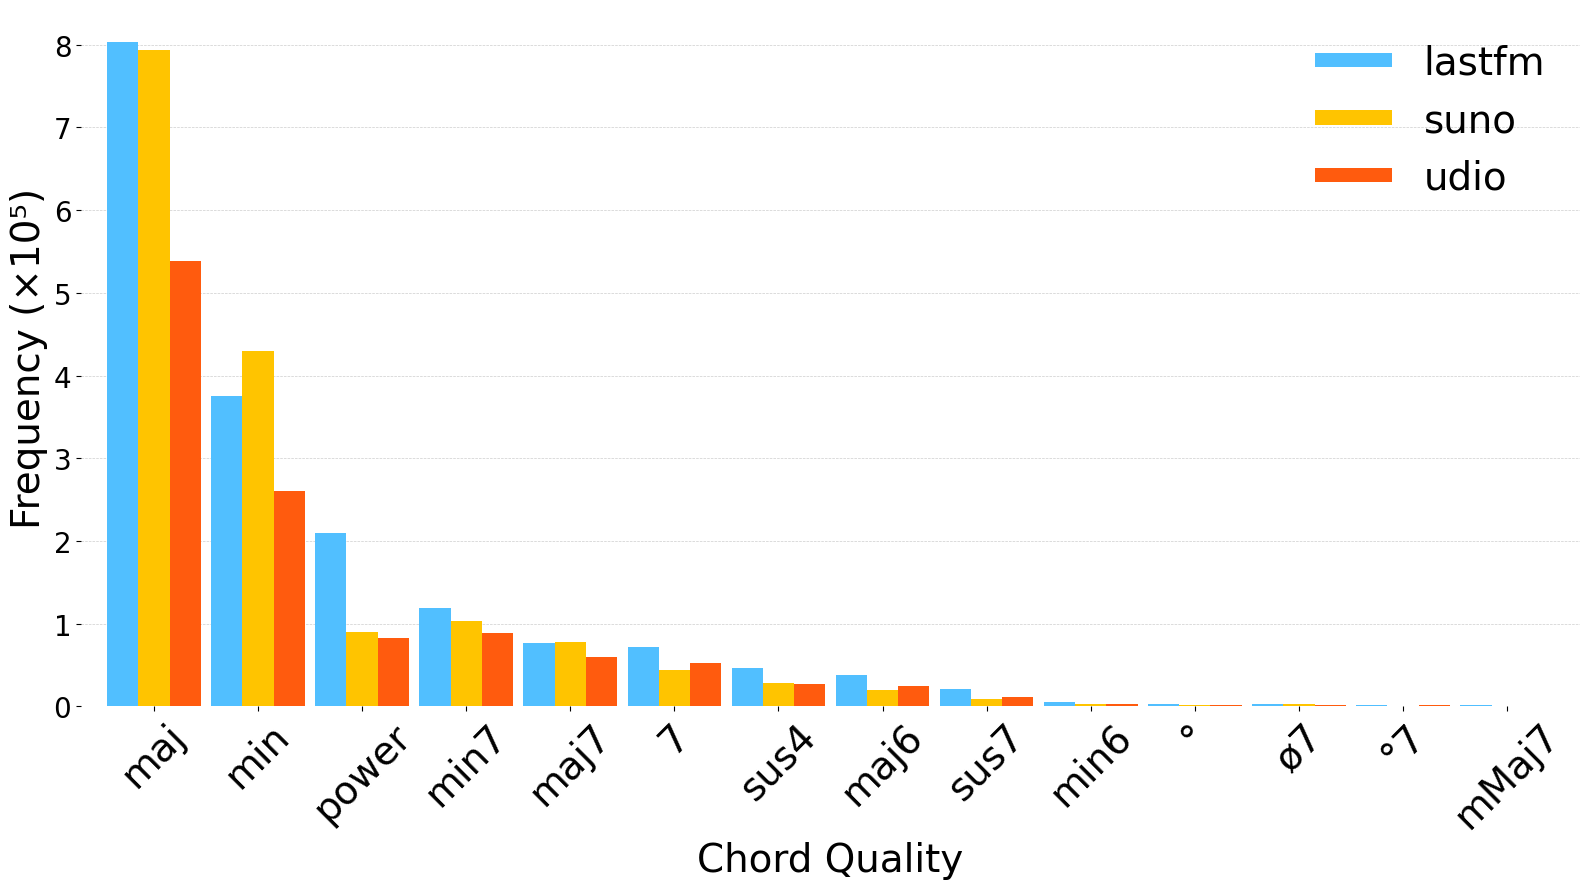

In [23]:
import matplotlib.pyplot as plt

# Scale counts to units of ×10⁵ for readable axis labels
df_plot = df_quality / 1e5

bar_colors = [colors[collections.index(col)] for col in df_plot.columns]

ax = df_plot.plot.bar(
    figsize=(16, 9),
    color=bar_colors,
    width=0.9
)
ax.set_axisbelow(True)                 # grid behind the bars
ax.grid(axis='y',                      # only horizontal lines
        linestyle='--',                # dashed
        linewidth=0.5,
        color="#cdcdcd",
        alpha=1.0)                   

textsize = 28
plt.xlabel("Chord Quality", fontsize=textsize, fontweight='normal')
plt.ylabel("Frequency (×10⁵)", fontsize=textsize, fontweight='normal')
plt.xticks(rotation=45, fontsize=textsize, fontweight='normal')
plt.yticks(fontsize=20, fontweight='normal')

plt.legend(
    title='',
    fontsize=textsize,
    title_fontsize=textsize,
    frameon=False,
    loc='upper right',
    handleheight=0.2,
    handlelength=2.
)

# Remove all plot borders/frames
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
